# Data assimulation 2

Within this lecture, we continue our discussion of data assimilation. Last time, we saw how Bayesian methods can be used to 
provide a complete solution of the data assimilation problem for deterministic and finite-dimensional dynamical systems. 
The issue, however, is that the computational cost of this method is too high to be applied directly within 
realistic applications where the dimensions of the state space can be very large. Are focus in this lecture 
is on the development of approximate forms for the full solution that are computationally tractable. To frame this 
discussion, we begin by reviewing the main ideas and notations from last time.

### Bayesian formulation and solution

We consider a dynamical system on an $m$-dimensional state space, $\mathbb{R}^{m}$, and write 
$\mathbf{x}$ for a state vector. The dynamics is governed by an evolution equation of the form
$$
\frac{\mathrm{d}\mathbf{x}}{\mathrm{d}t} = \mathbf{f}(\mathbf{x}), 
$$
with $\mathbf{f}(\mathbf{x})$ known as the dynamical rule. Given an initial condition, 
$\mathbf{x}(0) = \mathbf{x}_{0}$, this equation has a unique solution for all times. 
We write $\bm{\Phi}$ for the flow of the system, this being a mapping such that 
$\bm{\Phi}(\mathbf{x}_{0},t)$ is the state at time $t$ associated with the initial condition, $\mathbf{x}_{0}$, 
at time $t_{0}=0$. 
For convenience we write 
$$
\bm{\Phi}_{t}(\mathbf{x}_{0}) = \bm{\Phi}(\mathbf{x},t)
$$
for the induced mapping on the state space for time, $t$, this 
having the inverse 
$$
\bm{\Phi}_{t}^{-1}(\mathbf{x}) = \bm{\Phi}(\mathbf{x},-t).
$$

Suppose that at a set of times, $t_{1}, \dots, t_{n}$, we have noisy partial observations
$$
\mathbf{y}_{i} = \mathbf{g}_{i}[\mathbf{x}(t)] + \mathbf{z}_{i}, 
$$
where the $\mathbf{g}_{i}$ are observation functions that map to lower-dimensional observation spaces (which 
need not be the same), and $\mathbf{z}_{i}$ are random observational errors drawn from known error distributions. Our aim is to forecast the future 
state of the system for $t > t_{n}$. 

Within the Bayesian framework, we start with a prior probability distribution, $\pi_{0}$, on the initial 
state with PDF, $p_{0}$. To construct our forecast we follow 
a sequence of prediction-analysis steps:

At the $i$-th prediction step, our knowledge of the state at time $t_{i-1}$ is expressed through a distribution, $\tilde{\pi}_{i-1}$. We push forward this distribution under the flow of the dynamical system to obtain the prior distribution 
$$
\pi_{i} = \tilde{\pi}_{i-1} \circ \bm{\Phi}_{t_{i}-t_{i-1}}^{-1}, 
$$
for the state at time, $t_{i}$. 

The $i$-th analysis step then applies Bayes theorem to update this prior, $\tilde{\pi}_{i}$, in light of the ~
observations available at this time. In terms of the associated PDFs, this update takes the form
$$
\tilde{p}_{i}(\mathbf{x})  = \frac{q_{i}[\mathbf{y}_{i} - \mathbf{g}_{i}(\mathbf{x})] p_{i}(\mathbf{x})}{\int_{\mathbb{R}^{m}} q_{i}[\mathbf{y}_{i} - \mathbf{g}_{i}(\mathbf{x})] p_{i}(\mathbf{x}) \,\mathrm{d}\mathbf{x}}, 
$$
where $p_{i}$ is the prior PDF, $\tilde{p}_{i}$ the posterior PDF, and $q_{i}$ the PDF for the error distribution at this time.

The sequence is started using a prior distribution, $\pi_{0}$ for the initial state, and having assimilated all the observations
we arrive at a posterior distribution, $\tilde{\pi}_{t_{n}}$ at the final observation time. Our forecast
is then found by pushing forward $\tilde{\pi}_{t_{n}}$ to any desired time $t > t_{n}$.

If desired, we can also perform a reanalysis step in which  $\pi_{t_{n}}$ is pushed back to the initial time
to arrive at a posterior distribution, $\tilde{\pi}_{0}$, on the initial state. 






## Linear dynamical systems with Gaussian priors and errors

### The flow of a linear dynamical system

Recall that a dynamical system is linear if its evolution equation takes the form
$$
\frac{\mathrm{d}\mathbf{x}}{\mathrm{d}t} = \mathbf{A}\mathbf{x}, 
$$
with $\mathbf{A}$ a matrix that maps the state space to itself. The solution of this equation subject to 
the initial condition $\mathbf{x}(0) = \mathbf{x}_{0}$ takes the form
$$
\mathbf{x}(t) = \exp(\mathbf{A}t)\mathbf{x}_{0}, 
$$
where the exponential of a matrix is defined through the Taylor expansion, i.e., 
$$
\exp(\mathbf{A}) = \sum_{j=0}^{\infty} \frac{1}{j!}\mathbf{A}^{j}.
$$
The validity of the above solution can be verfied by differentiating the appropriate Taylor
series term by term. In practice, expontentials of matrices can be found using various
decompositions. For example, if $\mathbf{A}$ can be diagonalised, then we have 
$$
\mathbf{A} = \mathbf{U}^{T}\mathrm{diag}(\lambda_{1},\dots, \lambda_{m}) \mathbf{U}, 
$$
with $\mathbf{U}$ an orthogonal matrix. It is then easy to see that
$$
\exp(\mathbf{A}) =  \mathbf{U}^{T}\mathrm{diag}(\mathrm{e}^{\lambda_{1}},\dots, \mathrm{e}^{\lambda_{m}}) \mathbf{U}.
$$

It follows that the flow of a linear dynamical system takes the form
$$
\bm{\Phi}(\mathbf{x}_{0},t) = \exp( \mathbf{A} t)\mathbf{x}_{0}, 
$$
and hence the induced mapping, $\bm{\Phi}_{t}$, is linear.

### Linearisation of a dynamical system about equilibrium

While some physical systems are described by linear equations, it is more usual for linear equations to be obtained as 
an approximation to the full dynamics. 

An **equilibrium state**, $\mathbf{x}_{0}$, of a dynamical system is defined through the condition
$$
\mathbf{f}(\mathbf{x}_{0}) = \mathbf{0}.
$$
It is clear that if a system is in an equilibrium state at time, $t=0$, then it is in this state for all other times. 
With $\mathbf{x}_{0}$ an equilibrium state, consider the initial condition, $\mathbf{x}_{0} + \Delta\mathbf{x}_{0}$, with 
the perturbation term, $ \Delta\mathbf{x}_{0}$, suitably small. At a general time, $t$, we can then write the state as
$$
\mathbf{x}(t) = \mathbf{x}_{0} + \Delta \mathbf{x}(t) + o(\|\Delta\mathbf{x}_{0}\|).
$$
Putting this expansion into the evolution equation and retaining only first-order terms we obtain
$$
\frac{\mathrm{d}\Delta \mathbf{x}}{\mathrm{d}t} = \frac{\partial \mathbf{f}}{\partial \mathbf{x}}(\mathbf{x}_{0}) \Delta \mathbf{x}, 
$$
which is subject to the initial condition, $\Delta\mathbf{x}(0) = \Delta \mathbf{x}_{0}$. In this manner, we have arrived at a linear 
dynamical system that describes the evolution of sufficiently small perturbations to the state of the full system about 
equilibrium. Recalling the definition of the sensitivity matrix from last lecture, we note that
$$
\Delta\mathbf{x}(t) = \frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}(\mathbf{x}_{0})\Delta \mathbf{x}_{0}.
$$


These ideas are readily applied to the pendulum system for which we recall that 
$$
\mathbf{f}(\mathbf{x}) = \left(\begin{array}{c}
              \frac{1}{ml^{2}}p \\ - mgl \sin \theta
             \end{array}\right), 
$$
while we have
$$
\frac{\partial \mathbf{f}}{\partial \mathbf{x}}[\mathbf{x}(t)] = \left(\begin{array}{cc}
              0 && \frac{1}{ml^{2}} \\ - mgl \cos \theta && 0
             \end{array}\right).
$$
By inspection, an equilibrium state is
$$
\mathbf{x}_{0} = \left(\begin{array}{c}
             0 \\ 0
             \end{array}\right), 
$$
and hence the linearised equations of motion take the form
$$
\frac{\mathrm{d}}{\mathrm{d}t }\left(\begin{array}{c}
             \Delta \theta \\ \Delta p
             \end{array}\right) = \left(\begin{array}{cc}
              0 && \frac{1}{ml^{2}} \\ - mgl  && 0
             \end{array}\right) \left(\begin{array}{c}
             \Delta \theta \\ \Delta p
             \end{array}\right).
$$
As many of you will know, these are just the equations of simple harmonic motion. For the pendulum system, there is a further equilbrium point at 
$$
\mathbf{x}_{0} = \left(\begin{array}{c}
             \pi \\ 0
             \end{array}\right). 
$$
Phyically, it is clear that the first of these equilbrium points is stable, while the latter is not. The idea of stablility can readily be formalised, 
but for our purposes we just note that linearised approximations to the dynamics are only useful around stable equilibrium states. 

In the code block below, we compare the accuracy of the linearised dynamics for the pendulum. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from data_assimilation import pendulum

# Setup Parameters
params = {'L': 1.0, 'm': 1.0, 'g': 1.0}
t_points = np.linspace(0, 50, 500)

# Set the initial perturbation
theta_0 = 175
y0 = [np.deg2rad(theta_0), 0.0] 

# Solve both models using the dimension-agnostic engine
# True Non-linear physics
sol_nl = pendulum.solve_trajectory(
    pendulum.single.physics.eom, y0, t_points, args=tuple(params.values())
)

# Linearization at equilibrium
sol_l = pendulum.solve_trajectory(
    pendulum.single.physics.eom_linear_static, y0, t_points, args=tuple(params.values())
)

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- Subplot 1: Angle (Theta) ---
ax1.plot(t_points, sol_nl[0], 'k-', lw=2, label='Non-linear (True)')
ax1.plot(t_points, sol_l[0], 'r--', lw=2, label='Linear (Approx)')
ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("Evolution of Angle")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Momentum (p) ---
ax2.plot(t_points, sol_nl[1], 'k-', lw=2, label='Non-linear (True)')
ax2.plot(t_points, sol_l[1], 'r--', lw=2, label='Linear (Approx)')
ax2.set_ylabel(r"$p$ (momentum)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Evolution of Momentum")
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Accuracy of Linearization (Initial $\\theta_{{0}} = {theta_0}^\\circ$)', fontsize=14)
plt.tight_layout()
plt.show()


### Multivariate Gaussian distributions

A Gaussian distribution on $\mathbb{R}^{m}$ has PDF of the form
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{C}^{-1}(\mathbf{x}-\overline{\mathbf{x}})
    \right], 
$$
where $\overline{\mathbf{x}}$ is the **mean** value and $\mathbf{C}$ is the **covariance**, with the 
latter being a symmetric and invertible matrix (singular covariances can be defined but 
we do not need to consider this case). 

For a general PDF on $\mathbb{R}^{m}$, its mean is defined by 
$$
\overline{\mathbf{x}} = \int_{\mathbb{R}^{m}} \mathbf{x} p(\mathbf{x}) \,\mathrm{d}\mathbf{x}, 
$$
while its covariance is given by 
$$
\mathbf{Q} = \int_{\mathbb{R}^{m}} (\mathbf{x}-\overline{\mathbf{x}}) (\mathbf{x}-\overline{\mathbf{x}})^{T} p(\mathbf{x}) \,\mathrm{d}\mathbf{x}. 
$$
It can be shown that these definitions are consistent with the parameters occurring within the Gaussian 
distributions. 

Clearly, a Gaussian distribution is uniquely determined by its mean and covariance. For convenience, we write $\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$ for the 
Gaussian distribution with mean, $\overline{\mathbf{x}}$ and covariance, $\mathbf{Q}$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Define Gaussian parameters for the pendulum state [theta, p]
# Mean centered at a slight displacement
mean_state = np.array([0.5, 0.0]) 

# Covariance matrix representing uncertainty and correlation
# A positive off-diagonal indicates theta and p are positively correlated
cov_matrix = np.array([
    [0.20, 0.10], 
    [0.10, 0.15]
])

# Create the distribution object
dist = multivariate_normal(mean=mean_state, cov=cov_matrix)

# Setup the grid for PDF visualization
res = 100
theta_vals = np.linspace(-2, 2, res)
p_vals = np.linspace(-1.5, 1.5, res)
THETA, P = np.meshgrid(theta_vals, p_vals)
pos = np.dstack((THETA, P))
Z = dist.pdf(pos)

# Generate discrete samples (representing an ensemble of pendulums)
n_samples = 400
samples = dist.rvs(size=n_samples)

# Visualization
fig, ax = plt.subplots(figsize=(9, 7))

# Plot the PDF contours
contour = ax.contourf(THETA, P, Z, levels=20, cmap='viridis', alpha=0.8)
fig.colorbar(contour, label='Probability Density')

# Plot ensemble samples
ax.scatter(samples[:, 0], samples[:, 1], s=8, color='white', alpha=0.4, label='Ensemble Samples')

# Mark the mean state
ax.plot(mean_state[0], mean_state[1], 'r*', markersize=15, label=r'Mean State ($\bar{\mathbf{x}}$)')

ax.set_title(r"2D Gaussian Distribution in Phase Space ($\theta, p$)", fontsize=14)
ax.set_xlabel(r"Angle $\theta$ (rad)")
ax.set_ylabel(r"Momentum $p$")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


### Push forward of a Gaussian distribution under a linear flow 

Recall from the last lecture that a distribtion $\pi$ with PDF, $p$, is transformed to 
$$
p_{t}(\mathbf{x}) = p_{0}[\bm{\Phi}_{t}^{-1}(\mathbf{x})]  \det\!\left\{
    \frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}[\bm{\Phi}_{t}^{-1}(\mathbf{x})]\right\}, 
$$
under the flow of a dynamical system. When the dynamical system is linear and 
the initial distribution is Gaussian, we will now see that the push-forward is 
also Gaussiam and obtain simple expressions for its mean and covariance. 

First, for a linear dynamical system the flow induces a linear mapping, and hence
$$
\frac{\partial \Phi_{t}}{\partial \mathbf{x}_{0}}[\bm{\Phi}_{t}^{-1}(\mathbf{x})] = \exp(\mathbf{A} t).
$$
Starting from a Gaussian distribution, $\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$, we then find 
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathrm{e}^{-\mathbf{A}t}\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{C}^{-1}
    (\mathrm{e}^{-\mathbf{A}t}\mathbf{x}-\overline{\mathbf{x}})
    \right]  \det \exp(\mathbf{A} t)., 
$$
which through a simple factorisation takes the Gaussian form
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}_{t}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}}_{t})^{T}\mathbf{C}_{t}^{-1}
    (\mathbf{x}-\overline{\mathbf{x}}_{t})
    \right], 
$$
where we have defined 
$$
\overline{\mathbf{x}}_{t} = \exp(\mathbf{A} t)\overline{\mathbf{x}}, \quad 
\mathbf{Q}_{t} = \exp(\mathbf{A} t)\mathbf{Q} \exp(\mathbf{A} t)^{T}.
$$
It is easy to see that $\exp(\mathbf{A} t)^{T} = \exp(\mathbf{A}^{T} t)$, and hence
the transformed covariance can also be written 
$$
\mathbf{Q}_{t} = \exp(\mathbf{A} t)\mathbf{Q} \exp(\mathbf{A}^{T} t).
$$










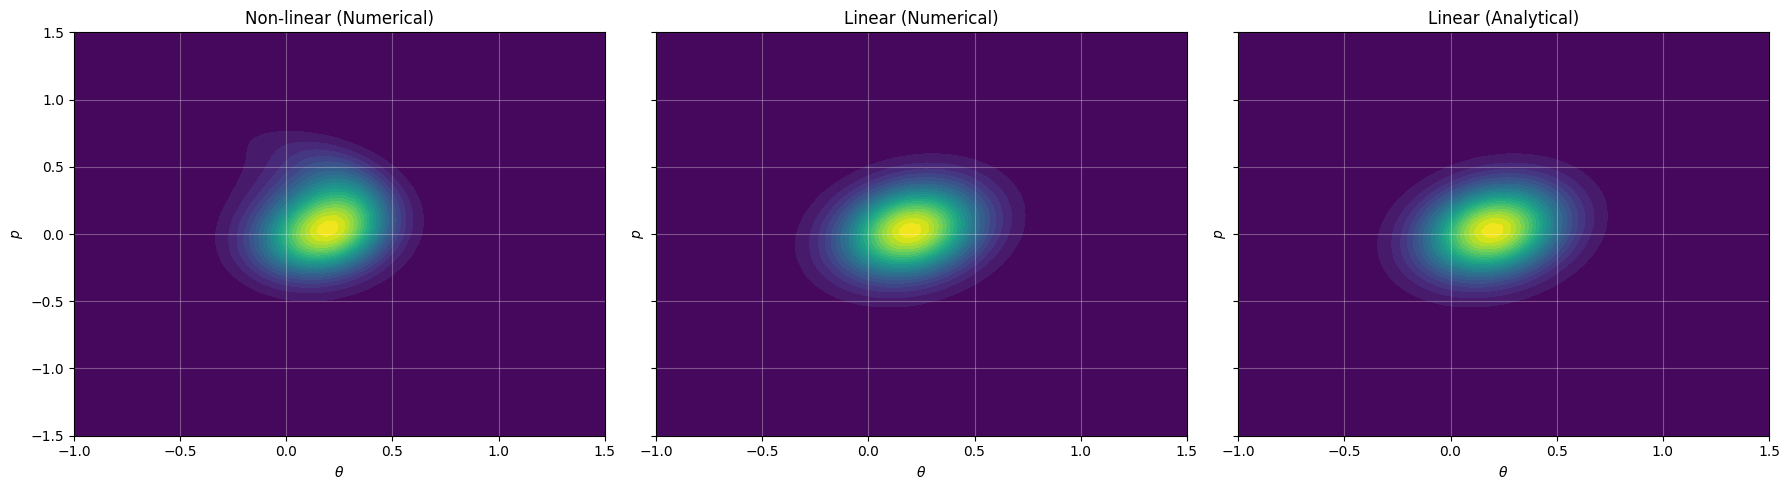

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from data_assimilation import pendulum

# 1. Setup Parameters and Initial Correlated Prior
t_final = 25.0
params = {'L': 1.0, 'm': 1.0, 'g': 1.0}
mean_0 = np.array([0.2, 0.0]) 
cov_0 = np.array([[0.05, 0.01], [0.01, 0.05]]) 

# Create the prior function using the package's factory
prior_func = pendulum.core.get_gaussian_pdf_func(mean_0, cov_0)

# 2. Method A: Non-linear Push-forward (Numerical Grid)
X, Y, _, Z_nl = pendulum.single.advect_pdf(
    prior_func, t_final=t_final, res=150, **params
)

# 3. Method B: Linearized Numerical Push-forward (Numerical Grid)
_, _, _, Z_l_grid = pendulum.single.advect_pdf(
    prior_func, 
    t_final=t_final, 
    eom_func=pendulum.single.physics.eom_linear_static, 
    res=150, 
    **params
)

# 4. Method C: Analytical Mapping (Mean and Covariance)
# Use the validated propagator
Phi = pendulum.single.physics.get_linear_propagator(t_final, **params)
mean_t = Phi @ mean_0 
cov_t = Phi @ cov_0 @ Phi.T 

# Evaluate via the updated library-based function in visualisation.py
Z_analytical = pendulum.single.evaluate_gaussian_pdf(X, Y, mean_t, cov_t)

# 5. Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
titles = ["Non-linear (Numerical)", "Linear (Numerical)", "Linear (Analytical)"]
grids = [Z_nl, Z_l_grid, Z_analytical]

for ax, data, title in zip(axes, grids, titles):
    # Use the simple plot helper
    pendulum.single.plot_pdf(X, Y, data, ax=ax, title=title)
    
    # Ensure grid lines are visible and limits are consistent
    ax.grid(True, color='white', alpha=0.3, zorder=10)
    ax.set_xlim(-1, 1.5)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

### Updating a Gaussian prior

Suppose that our initial knowledge of the state, $\mathbf{x}$, is described by the Gaussian prior, 
$\mathcal{N}(\overline{\mathbf{x}},\mathbf{Q})$. We are given a noisy partial observation 
$$
\mathbf{y} = \mathbf{B}\mathbf{x} + \mathbf{z}, 
$$
where $\mathbf{B}$ is a matrix that maps to a lower-dimensional observation space, and 
$\mathbf{z}$ is a random error drawn from the error distribution $\mathcal{N}(\mathbf{0}, \mathbf{R})$. 
Errors with non-zero means can also be handled, but it is always possible to reduce to the zero-mean 
case by pre-processing the data. Using Bayes theorem, we can then determine the posterior distribution 
for $\mathbf{x}$. In this case, the prior PDF takes the form
$$
p(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{Q}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{x}-\overline{\mathbf{x}})^{T}\mathbf{C}^{-1}(\mathbf{x}-\overline{\mathbf{x}})
    \right], 
$$
while the likelihood is given by
$$
q(\mathbf{y}-\mathbf{B}\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^{m} \det\mathbf{R}}}
\mathrm{exp}\!\left[
    -\frac{1}{2}(\mathbf{y}-\mathbf{B}\mathbf{x})^{T}\mathbf{C}^{-1}(\mathbf{y}-\mathbf{B}\mathbf{x})
    \right].
$$
The product of these two PDFs is clearly proportional to the exponential of a quadratic function 
of $\mathbf{x}$, with this suggesting that the posterior is also Gaussian. This is indeed true, 
and it can be shown that posterior distribution has mean
$$
\tilde{\mathbf{x}} = \overline{\mathbf{x}} + \mathbf{Q}\mathbf{B}^{T}(\mathbf{B}\mathbf{Q}\mathbf{B}^{T} + \mathbf{R})^{-1}
(\mathbf{y} - \mathbf{B}\overline{\mathbf{x}}), 
$$
and covariance
$$
\tilde{\mathbf{Q}} = \mathbf{Q} - \mathbf{Q}\mathbf{B}^{T}(\mathbf{B}\mathbf{Q}\mathbf{B}^{T} + \mathbf{R})^{-1}
\mathbf{B}\mathbf{Q}.
$$

### The Kalman filter